In [2]:
# Cell 01: 生成合成蔬菜批发样本并保存为 CSV
import sys
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta
np.random.seed(42)

ROOT = Path.home() / "projects" / "retail_dashboard"
DATA_DIR = ROOT / "data"; DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = ROOT / "outputs"; OUT_DIR.mkdir(parents=True, exist_ok=True)
P = DATA_DIR / "veg_wholesale_sample.csv"

start = datetime(2019,1,1)
end = datetime(2021,12,31)
days = (end - start).days + 1
date_index = [start + timedelta(days=i) for i in range(days)]

cities = ["Beijing","Shanghai","Guangzhou","Shenzhen","Chengdu","Wuhan","Xi'an","Nanjing"]
vegetables = ["白菜","西红柿","黄瓜","土豆","菠菜","青椒","茄子"]

rows = []
for city in cities:
    for veg in vegetables:
        base = {
            "白菜":2.0,"西红柿":4.0,"黄瓜":3.5,"土豆":2.2,"菠菜":3.0,"青椒":4.5,"茄子":4.0
        }[veg]
        amp = base * 0.3 + np.random.rand()*0.2
        trend = np.random.uniform(-0.0003,0.0007)
        noise_scale = base * 0.08
        for i, d in enumerate(date_index):
            day_of_year = d.timetuple().tm_yday
            seasonal = amp * np.sin(2 * np.pi * day_of_year / 365.25)
            weekly = 0.05*base * (1 if d.weekday() in (5,6) else 0)
            fest = 0
            if (d.month == 1 and d.day>=15) or (d.month == 2 and d.day<=15):
                fest = base * np.random.uniform(0.05,0.25)
            shock = 0
            if np.random.rand() < 0.001:
                shock = base * np.random.uniform(0.3,0.8)
            price = max(0.2, base + seasonal + trend*i + weekly + fest + shock + np.random.normal(0, noise_scale))
            volume = max(1, int(2000 * (1 + np.random.normal(0,0.1)) * (base/price)))
            rows.append({
                "date": d,
                "city": city,
                "vegetable": veg,
                "wholesale_price": round(price, 2),
                "volume_kg": volume,
                "origin_province": np.random.choice(["Hebei","Shandong","Henan","Sichuan","Guangdong"])
            })

df = pd.DataFrame(rows)
df.to_csv(P, index=False, encoding="utf-8-sig")
print("Sample data saved to:", P)
print("shape:", df.shape)
print(df.head(10).to_string(index=False))

Sample data saved to: C:\Users\Lenovo\projects\retail_dashboard\data\veg_wholesale_sample.csv
shape: (61376, 6)
      date    city vegetable  wholesale_price  volume_kg origin_province
2019-01-01 Beijing        白菜             1.83       2250           Henan
2019-01-02 Beijing        白菜             1.70       2234           Henan
2019-01-03 Beijing        白菜             1.94       1950       Guangdong
2019-01-04 Beijing        白菜             2.05       1866        Shandong
2019-01-05 Beijing        白菜             2.20       1681         Sichuan
2019-01-06 Beijing        白菜             2.09       1939           Henan
2019-01-07 Beijing        白菜             2.04       1956           Hebei
2019-01-08 Beijing        白菜             2.00       2188       Guangdong
2019-01-09 Beijing        白菜             2.23       1593         Sichuan
2019-01-10 Beijing        白菜             2.25       1558        Shandong


In [7]:
# Cell 02: 读取样本并打印 shape / head / info
import pandas as pd
from pathlib import Path

P = Path.home() / "projects" / "retail_dashboard" / "data" / "veg_wholesale_sample.csv"
df = pd.read_csv(P, parse_dates=["date"])
print("shape:", df.shape)
print("\n--- HEAD ---")
print(df.head(10).to_string(index=False))
print("\n--- INFO ---")
df.info()
# 保存到 globals 方便后续 cell 使用
globals()['df_veg'] = df
# Quick EDA: date range, uniques, basic stats, zeros/negatives, duplicates, top prices, simple outlier flags

shape: (61376, 6)

--- HEAD ---
      date    city vegetable  wholesale_price  volume_kg origin_province
2019-01-01 Beijing        白菜             1.83       2250           Henan
2019-01-02 Beijing        白菜             1.70       2234           Henan
2019-01-03 Beijing        白菜             1.94       1950       Guangdong
2019-01-04 Beijing        白菜             2.05       1866        Shandong
2019-01-05 Beijing        白菜             2.20       1681         Sichuan
2019-01-06 Beijing        白菜             2.09       1939           Henan
2019-01-07 Beijing        白菜             2.04       1956           Hebei
2019-01-08 Beijing        白菜             2.00       2188       Guangdong
2019-01-09 Beijing        白菜             2.23       1593         Sichuan
2019-01-10 Beijing        白菜             2.25       1558        Shandong

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 61376 entries, 0 to 61375
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
-

In [9]:
# 一段代码完成 EDA + group z-score + 输出异常明细与汇总
import pandas as pd
import numpy as np

# 取已加载的数据
df = globals().get('df_veg')
if df is None:
    from pathlib import Path
    P = Path.home() / "projects" / "retail_dashboard" / "data" / "veg_wholesale_sample.csv"
    df = pd.read_csv(P, parse_dates=["date"])
    globals()['df_veg'] = df

# 基本列与计算
df = df.copy()
df['revenue'] = (df['wholesale_price'] * df['volume_kg']).round(2)

print("1) 基本信息")
print("Total rows:", len(df))
print("Date range:", df['date'].min(), "->", df['date'].max())
print("Cities (count):", df['city'].nunique(), "Vegetables (count):", df['vegetable'].nunique())

print("\n2) 数值列概览")
print(df[['wholesale_price','volume_kg','revenue']].describe().round(2))

print("\n3) 零或负值 & 重复检查")
print("wholesale_price <= 0:", (df['wholesale_price'] <= 0).sum())
print("volume_kg <= 0:", (df['volume_kg'] <= 0).sum())
print("exact duplicate rows:", df.duplicated().sum())

print("\n4) 各蔬菜价格统计（按 mean 降序）")
veg_stats = df.groupby('vegetable')['wholesale_price'].agg(['count','mean','std','min','max']).round(2).sort_values('mean', ascending=False)
print(veg_stats.to_string())

print("\n5) 价格极值样例（Top 10 highest prices）")
print(df.sort_values('wholesale_price', ascending=False).head(10).to_string(index=False))

# 6) 计算分组 z-score（安全处理 std==0 与 NaN）
def safe_z(s):
    std = s.std(ddof=0)
    if std == 0 or np.isnan(std):
        return (s - s.mean()) * 0.0  # all zeros
    return (s - s.mean()) / std

df['z'] = df.groupby(['city','vegetable'])['wholesale_price'].transform(safe_z)
df['z'] = df['z'].fillna(0.0)

# 7) 异常筛选与显示（可调整阈值 threshold）
threshold = 4.0
anoms = df[df['z'].abs() > threshold].sort_values('z', key=lambda s: s.abs(), ascending=False)
print(f"\nAnomalies count (|z|>{threshold}):", len(anoms))
if len(anoms) > 0:
    print("\n异常明细 (前 20)：")
    print(anoms[['date','city','vegetable','wholesale_price','volume_kg','origin_province','z']].head(20).to_string(index=False))
else:
    print("没有检测到超过阈值的异常点。")

# 8) 异常按 city-vegetable 汇总与按蔬菜汇总
if len(anoms) > 0:
    anoms_count = anoms.groupby(['city','vegetable']).size().reset_index(name='anomaly_count').sort_values('anomaly_count', ascending=False)
    print("\n按 city-vegetable 汇总的异常计数（前 20）：")
    print(anoms_count.head(20).to_string(index=False))

    veg_anom = anoms.groupby('vegetable').size().reset_index(name='anomaly_count').sort_values('anomaly_count', ascending=False)
    print("\n按蔬菜汇总的异常计数：")
    print(veg_anom.to_string(index=False))
else:
    print("\n无异常时，跳过异常汇总。")
    # 9) 如果你想把异常保存为 CSV，解除下面注释并运行一次
# outp = Path.home() / "projects" / "retail_dashboard" / "outputs" / "veg_price_anomalies_z4.csv"
# anoms.to_csv(outp, index=False, encoding="utf-8-sig")
# print("\nAnomalies saved to:", outp)

1) 基本信息
Total rows: 61376
Date range: 2019-01-01 00:00:00 -> 2021-12-31 00:00:00
Cities (count): 8 Vegetables (count): 7

2) 数值列概览
       wholesale_price  volume_kg   revenue
count         61376.00   61376.00  61376.00
mean              3.54    1990.05   6624.57
std               1.26     577.05   1887.02
min               0.82     746.00   2565.13
25%               2.59    1538.00   4725.08
50%               3.36    1862.00   6848.60
75%               4.48    2353.00   8125.20
max               9.43    6043.00  12126.44

3) 零或负值 & 重复检查
wholesale_price <= 0: 0
volume_kg <= 0: 0
exact duplicate rows: 0

4) 各蔬菜价格统计（按 mean 降序）
           count  mean   std   min   max
vegetable                               
青椒          8768  4.80  1.14  1.86  9.35
茄子          8768  4.23  1.00  1.70  9.43
西红柿         8768  4.19  1.00  1.73  7.40
黄瓜          8768  3.76  0.90  1.54  7.30
菠菜          8768  3.22  0.80  1.06  5.39
土豆          8768  2.40  0.60  0.95  4.26
白菜          8768  2.20  0.57  0.82  4.74

Rolling volatility summary saved to: C:\Users\Lenovo\projects\retail_dashboard\outputs\veg_volatility_full.csv
Saved price anomalies to: C:\Users\Lenovo\projects\retail_dashboard\outputs\veg_anomalies_rolling_price.csv
Saved supply risk candidates to: C:\Users\Lenovo\projects\retail_dashboard\outputs\veg_anomalies_supply_risk.csv
Saved demand spike candidates to: C:\Users\Lenovo\projects\retail_dashboard\outputs\veg_anomalies_demand_spike.csv
Total rows in daily aggregated: 61376
Price anomalies (rolling z>|3.0|): 191
Supply risk candidates (price up + volume down): 85
Demand spike candidates (price up + volume up): 1

Price anomalies (top 10 by |z|):
      date     city vegetable  avg_price  rolling_mean  rolling_std  rolling_z  total_volume  vol_pct_ch
2020-03-28    Xi'an        茄子       9.43      5.410667     0.815695   4.927496           909   -0.382892
2019-03-30  Chengdu        白菜       4.74      2.748000     0.415754   4.791300           792   -0.457534
2020-01-05 Shanghai      

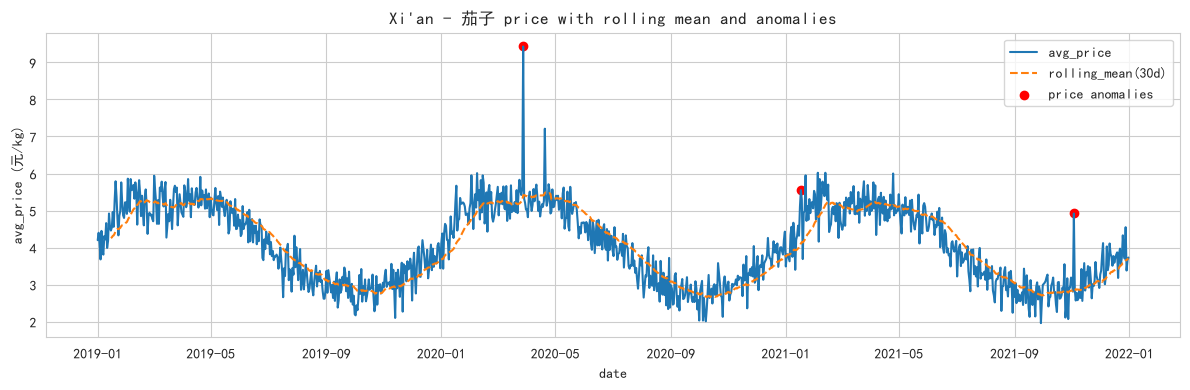

Total supply risk candidates: 85
     city vegetable  level_2       date  avg_price  total_volume  total_revenue  price_pct_ch  vol_pct_ch  rolling_vol  rolling_mean  rolling_std  rolling_z  price_anom  vol_drop  vol_rise  supply_risk  demand_spike  price_shock_any
 Shenzhen        青椒    44927 2021-12-23       7.32          1312        9603.84      0.375940   -0.226871     0.153656      4.644667     0.665747   4.018545        True      True     False         True         False             True
  Chengdu        茄子    10927 2021-11-29       4.95          1544        7642.80      0.490964   -0.287494     0.180948      3.585333     0.444745   3.068425        True      True     False         True         False             True
  Chengdu        土豆     8733 2021-11-27       2.30          1596        3670.80      0.385542   -0.427547     0.194501      1.560333     0.199663   3.704571        True      True     False         True         False             True
    Wuhan        白菜    48172 2021-1

In [15]:
# Rolling volatility + rolling z-score 异常检测
# 目的：按 city+vegetable 做日度聚合，计算滚动波动与滚动 z-score，
#       用价格变化 + 体积变化的组合规则识别供给风险 / 需求激增 / 价格异常，
#       并将结果保存为 CSV，绘制示例时序图以便人工核查。
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

#设置全局中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方框的问题

# 读取数据
df = globals().get('df_veg')
if df is None:
    P = Path.home() / "projects" / "retail_dashboard" / "data" / "veg_wholesale_sample.csv"
    df = pd.read_csv(P, parse_dates=["date"])
df = df.copy()

# 日度聚合
daily = df.groupby(['date','city','vegetable'], as_index=False).agg(
    avg_price=('wholesale_price','mean'),
    total_volume=('volume_kg','sum'),
)
daily['total_revenue'] = (daily['avg_price'] * daily['total_volume']).round(2)
daily = daily.sort_values(['city','vegetable','date']).reset_index(drop=True)
daily['price_pct_ch'] = daily.groupby(['city','vegetable'])['avg_price'].pct_change()
daily['vol_pct_ch'] = daily.groupby(['city','vegetable'])['total_volume'].pct_change()

# compute_rolling 定义
def compute_rolling(g):
    g = g.sort_values('date').copy()
    g['rolling_vol'] = g['price_pct_ch'].rolling(window=14, min_periods=7).std()
    g['rolling_mean'] = g['avg_price'].rolling(window=30, min_periods=15).mean()
    g['rolling_std'] = g['avg_price'].rolling(window=30, min_periods=15).std()
    g['rolling_z'] = (g['avg_price'] - g['rolling_mean']) / g['rolling_std'].replace({0: np.nan})
    return g

# 使用 reset_index()（不要 drop=True），这样 'city' 与 'vegetable' 会被恢复为列
vol = daily.groupby(['city','vegetable']).apply(compute_rolling).reset_index()  

# 下面的逻辑保持不变：标注异常、保存 CSV、打印摘要与画图
price_z_threshold = 3.0
vol_drop_threshold = -0.20
vol_rise_threshold = 0.20

vol['price_anom'] = vol['rolling_z'].abs() > price_z_threshold
vol['vol_drop'] = vol['vol_pct_ch'] < vol_drop_threshold
vol['vol_rise'] = vol['vol_pct_ch'] > vol_rise_threshold
vol['supply_risk'] = (vol['rolling_z'] > price_z_threshold) & vol['vol_drop']
vol['demand_spike'] = (vol['rolling_z'] > price_z_threshold) & vol['vol_rise']
vol['price_shock_any'] = vol['price_anom']

OUT = Path.home() / "projects" / "retail_dashboard" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

vol.to_csv(OUT / "veg_volatility_full.csv", index=False, encoding="utf-8-sig")
(vol[vol['price_shock_any']].sort_values('rolling_z', key=lambda s: s.abs(), ascending=False)
   .to_csv(OUT / "veg_anomalies_rolling_price.csv", index=False, encoding="utf-8-sig"))
(vol[vol['supply_risk']].sort_values('rolling_z', ascending=False)
   .to_csv(OUT / "veg_anomalies_supply_risk.csv", index=False, encoding="utf-8-sig"))
(vol[vol['demand_spike']].sort_values('rolling_z', ascending=False)
   .to_csv(OUT / "veg_anomalies_demand_spike.csv", index=False, encoding="utf-8-sig"))

anoms_price = vol[vol['price_shock_any']].sort_values('rolling_z', key=lambda s: s.abs(), ascending=False)
anoms_supply = vol[vol['supply_risk']].sort_values('rolling_z', ascending=False)
anoms_demand = vol[vol['demand_spike']].sort_values('rolling_z', ascending=False)

print("Rolling volatility summary saved to:", OUT / "veg_volatility_full.csv")
print("Saved price anomalies to:", OUT / "veg_anomalies_rolling_price.csv")
print("Saved supply risk candidates to:", OUT / "veg_anomalies_supply_risk.csv")
print("Saved demand spike candidates to:", OUT / "veg_anomalies_demand_spike.csv")
print("Total rows in daily aggregated:", len(vol))
print("Price anomalies (rolling z>|{:.1f}|): {}".format(price_z_threshold, len(anoms_price)))
print("Supply risk candidates (price up + volume down):", len(anoms_supply))
print("Demand spike candidates (price up + volume up):", len(anoms_demand))

print("\nPrice anomalies (top 10 by |z|):")
print(anoms_price[['date','city','vegetable','avg_price','rolling_mean','rolling_std','rolling_z','total_volume','vol_pct_ch']].head(10).to_string(index=False))

vol_summary = vol.groupby(['city','vegetable'])['rolling_vol'].mean().reset_index().rename(columns={'rolling_vol':'avg_rolling_vol'})
top_vol = vol_summary.sort_values('avg_rolling_vol', ascending=False).head(20)
print("\nTop 20 city-vegetable by avg rolling volatility:")
print(top_vol.to_string(index=False))

# 示例图（若有异常）
if len(anoms_price) > 0:
    sample = anoms_price.iloc[0]
    city0 = sample['city']; veg0 = sample['vegetable']
    sel = vol[(vol['city']==city0) & (vol['vegetable']==veg0)].sort_values('date')
    plt.figure(figsize=(12,4))
    plt.plot(sel['date'], sel['avg_price'], label='avg_price')
    plt.plot(sel['date'], sel['rolling_mean'], label='rolling_mean(30d)', linestyle='--')
    anomaly_points = sel[sel['price_anom']]
    plt.scatter(anomaly_points['date'], anomaly_points['avg_price'], color='red', label='price anomalies')
    plt.title(f"{city0} - {veg0} price with rolling mean and anomalies")
    plt.xlabel("date")
    plt.ylabel("avg_price (元/kg)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No rolling price anomalies to plot.")
    # 快速查看 supply risk 异常并保存审核表（运行在已生成 outputs 的环境下）


OUT = Path.home() / "projects" / "retail_dashboard" / "outputs"
supply_path = OUT / "veg_anomalies_supply_risk.csv"
report_path = OUT / "veg_supply_risk_for_review.csv"

if supply_path.exists():
    df_supply = pd.read_csv(supply_path, parse_dates=['date'])
    print("Total supply risk candidates:", len(df_supply))
    # 显示前 30 条供人工核查
    print(df_supply.sort_values(['date'], ascending=False).head(30).to_string(index=False))
    # 生成一个精简的审核表，方便发给采购（含判定列供填写）
    review_cols = ['date','city','vegetable','avg_price','rolling_z','total_volume','vol_pct_ch']
    review = df_supply[review_cols].copy()
    review['procurement_action'] = ''   # 采购同事填：联系/替换/观察/无动作
    review.to_csv(report_path, index=False, encoding='utf-8-sig')
    print("Review CSV saved to:", report_path)
else:
    print("没有找到文件:", supply_path)
    print("请先运行波动检测步骤生成 veg_anomalies_supply_risk.csv")